<a href="https://colab.research.google.com/github/ParkHangah/AIFFEL_quest_eng/blob/master/LLM_Aplication/LLM02/BERT_PretraindeModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BERT pretrainde model 제작**

# 0. 사전준비

## 0-1.드라이브 연결 (코렙 사용자만 실행)

##### (1) 경로 설정을 사용사 환경에 맞게 해주세요

In [1]:
# 드라이브 경로 설정  by 박항아
drive_path = '#Study/Aiffel/Work' # 평상시 작업하는 드라이브 폴더 경로를 입력해 주세요.
project_name = 'bert_pretrain'       # 이번 프로젝트세 사용하는 폴더명을 입력해주세요.

##### (2) 드라이브 연결

In [ ]:
from google.colab import drive
from IPython.display import clear_output
import ipywidgets as widgets
import os

def inf(msg, style, wdth):
    inf = widgets.Button(description=msg, disabled=True, button_style=style, layout=widgets.Layout(min_width=wdth))
    display(inf)

# 1. 구글 드라이브 마운트
print("Connecting...")
drive.mount('/content/gdrive')

# 2. 경로 설정 및 폴더 생성
base_path = os.path.join('/content/gdrive/MyDrive',drive_path)
project_path = os.path.join(base_path, project_name)

# Create the project directory if it doesn't exist
os.makedirs(project_path, exist_ok=True)

print(f"base_path: {base_path}")
# 3. 폴더 생성
print(f"Selected Google Drive root path: {base_path}")
inf('\u2714 Done','success', '50px')

## 0-2. 데이터 타운로드

In [3]:
data_path = os.path.join(project_path, 'data')
model_path = os.path.join(project_path, 'models')

In [4]:
# ! mkdir -p "{data_path}"
# ! mkdir -p "{model_path}"
# ! wget https://aiffelstaticprd.blob.core.windows.net/media/documents/kowiki.txt.zip
# ! mv kowiki.txt.zip "{data_path}"
# ! cd "{data_path}" && unzip kowiki.txt.zip


---


# [프로젝트]

## 1. 라이브러리 설치

In [5]:
#다음 라이브러리를 설치해주세요
!pip install sentencepiece
!pip install tqdm
!conda install -y -c conda-forge ipywidgets
!jupyter nbextension enable --py widgetsnbextension
!pip install torchsummary

/bin/bash: line 1: conda: command not found
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [6]:
# 파이썬 2와 3의 호환성을 위해 표준 라이브러리 기능들을 불러옴
from __future__ import absolute_import, division, print_function, unicode_literals

# --- PyTorch 관련 라이브러리 ---
import torch
import torch.nn as nn             # 신경망 레이어 (Linear, Conv2d 등)
import torch.nn.functional as F   # 활성화 함수 (ReLU, Softmax 등)
import torch.optim as optim       # 최적화 알고리즘 (Adam, SGD 등)
from torch.utils.data import DataLoader, TensorDataset    # 데이터셋 관리 및 미니배치 생성
from torchsummary import summary  # 모델의 구조와 파라미터 수를 요약

# --- 시스템 및 데이터 처리 라이브러리 ---
import os             # 디렉토리 경로 제어
import re             # 정규표현식을 이용한 텍스트 전처리
import math           # 수학 연산 (Log, Pi 등)
import numpy as np    # 수치 행렬 연산
import pandas as pd   # 데이터프레임 활용 (CSV, Excel 처리)
import random         # 무작위 추출 및 셔플
import collections    # Counter 등 특수 컨테이너 타입 활용
import json           # 설정 파일(Config) 읽기 및 쓰기
import shutil         # 파일 복사 및 이동
import zipfile        # 압축 파일 해제 및 관리
import copy           # 객체 깊은 복사(Deep Copy)
from datetime import datetime   # 학습 시간 기록 및 로그 생성

# --- 시각화 및 특수 도구 ---
import matplotlib.pyplot as plt   # 학습 곡선(Loss, Accuracy) 시각화
import sentencepiece as spm       # 구글의 서브워드 토크나이저 (NLP 핵심 도구)
from tqdm.notebook import tqdm    # 학습 진행 상황을 프로그레스 바로 표시

# --- 재현성을 위한 설정 ---
# 실험을 할 때마다 동일한 결과가 나오도록 랜덤 시드를 고정함
random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
# 참고: PyTorch의 경우 torch.manual_seed(random_seed)도 추가하는 것이 좋습니다.

# 현재 설치된 PyTorch 버전을 출력하여 환경 확인
print(torch.__version__)

2.8.0+cu126


In [7]:
import matplotlib

print(torch.__version__)
print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
print(json.__version__)
print(re.__version__)

2.8.0+cu126
2.0.2
2.2.2
3.10.0
2.0.9
2.2.1


## 2. Tokenizer 준비

GPT의 BPE, BERT의 WordPiece 모델 등의 성공으로
subword 기반의 토크나이징 기법이 주요한 방법론으로 굳어짐  
- SentencePiece 기반의 토크나이저 준비:
https://github.com/google/sentencepiece

※ 경로는 좌측 사이드 바에 폴더 아이콘을 눌러 해당 파일과 폴더를 찾은 후 경로복사를 해서 쓸 것

```
# 코드로 형식 지정됨
```



```
$ python
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = '/content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/data/kowiki.txt'
>>> prefix = '/content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/models/ko_32000'
>>> vocab_size = 32000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")
```



In [ ]:
# ! python

Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = os.getenv('HOME')+'/content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/data/kowiki.txt'
>>> prefix = os.getenv('HOME')+'/content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/models/ko_32000'
>>> vocab_size = 32000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")
sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=/root/content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/data/kowiki.txt --model_prefix=/root/content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/models/ko_32000 --vocab_size=32007 --

In [8]:
# # 모델 이동
# ! mv ko_32000.* '{model_path}'

In [8]:
# data_dir = 'data'  # 드라이브 연결시 미리 했으므로 사용 X

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_path}/ko_32000.model")

True

In [9]:
#Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))
print(vocab_list)

['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동', '▁선', '▁나', '으며', '▁모', '▁연', '▁영', '▁의', '▁오', '▁마', '에는', '▁발', '▁소', '한다', '▁고', '▁개', '▁201', '▁구', '▁세', '▁도', '▁상', '▁비', '▁스', '▁국', '▁서', '▁후', '▁여', '▁200', '▁때', '▁4', '▁성', '▁해', '▁관', '▁있는', '▁신', '▁프', '▁대한', '부터', '▁5', '00', '▁방', '▁또', '지만', '▁(', '▁역', '되어', '▁않', '▁만', '▁"', '▁장', '▁바', '까지', '▁무', '▁남', '▁통', '▁현', '▁교', '▁같', '에게', '▁내', '학교', '▁문', '▁출', '▁거', '▁포', '▁결', '된다', '▁《', '적인', '이라', '▁6', '▁우', '적으로', '▁불', '▁원', '▁최', '▁진', '▁생', '▁작', '▁어', '▁당', '국의', '▁노', '▁강', '▁알', '▁반', '▁7', '▁8', '▁계', '▁따', '▁파', '▁분', '▁없', '▁받', '▁말', '면서', '들이', 'or', '되었', '▁사용', "▁'", '▁두', '▁실', '에서는', '▁10', '▁리', '들은', '▁명', '▁함', '▁단', '▁이후', '하기', '▁예', '년에', '),',

In [10]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


## 3. 데이터 전처리

### 3-1. Mask 생성 (1차 코드)

#### 1) Subword 기반 15% 마스킹

In [11]:
print(tokens_org)

# 전체 token의 15% mask
mask_cnt = int((len(tokens_org) - 3) * 0.15)
mask_cnt

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


10

**문제점**
- Subword 기반으로 토크나이징을 했을 때 _대, [MASK], 민국이라고 가운데를 마스킹 했을 경우 해당 [MASK]가 '한'일 거라는 건 너무 쉽게 맞출 수 있음. '대한민국'이라는 패턴을 아주 자주 보게 될 테니까요.
- 따라서 Masked LM 태스크를 구성할 땐 띄어쓰기 단위로 한꺼번에 마스킹해 주는 것이 좋음


#### 2) 띄어쓰기 기반 15% 마스킹

In [12]:
# 띄어쓰기 단위로 mask하기 위해서 index 분할
cand_idx = []  # word 단위의 index array
for (i, token) in enumerate(tokens_org):
    if token == "[CLS]" or token == "[SEP]":
        continue
    if 0 < len(cand_idx) and not token.startswith(u"\u2581"):  # u"\u2581"는 단어의 시작을 의미하는 값
        cand_idx[-1].append(i)
    else:
        cand_idx.append([i])

# 결과확인
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

[1, 2, 3] ['▁추적', '추', '적']
[4] ['▁비가']
[5] ['▁내리는']
[6, 7, 8] ['▁날', '이었', '어']
[9, 10] ['▁그날', '은']
[11, 12, 13] ['▁', '왠', '지']
[14, 15] ['▁손', '님이']
[16] ['▁많아']
[17] ['▁첫']
[18] ['▁번에']
[19, 20] ['▁삼', '십']
[21] ['▁전']
[22, 23] ['▁둘째', '번']
[24, 25] ['▁오', '십']
[26] ['▁전']
[27, 28] ['▁오랜', '만에']
[29, 30] ['▁받아', '보는']
[31] ['▁십']
[32, 33] ['▁전', '짜리']
[34, 35, 36] ['▁백', '통', '화']
[37, 38, 39] ['▁서', '푼', '에']
[41] ['▁손바닥']
[42, 43] ['▁위', '엔']
[44, 45] ['▁기쁨', '의']
[46, 47] ['▁눈', '물이']
[48] ['▁흘러']
[49, 50, 51] ['▁컬', '컬', '한']
[52] ['▁목에']
[53, 54] ['▁모', '주']
[55, 56, 57] ['▁한', '잔', '을']
[58, 59] ['▁적', '셔']
[60] ['▁몇']
[61] ['▁달']
[62] ['▁포']
[63] ['▁전부터']
[64, 65, 66] ['▁콜', '록', '거리는']
[67] ['▁아내']
[68] ['▁생각에']
[69, 70] ['▁그', '토록']
[71] ['▁먹고']
[72, 73] ['▁싶다', '던']


In [13]:
# random mask를 위해서 index 순서를 섞음
random.shuffle(cand_idx)
cand_idx

[[18],
 [44, 45],
 [24, 25],
 [49, 50, 51],
 [31],
 [63],
 [41],
 [52],
 [22, 23],
 [71],
 [17],
 [19, 20],
 [60],
 [32, 33],
 [62],
 [46, 47],
 [29, 30],
 [72, 73],
 [6, 7, 8],
 [64, 65, 66],
 [67],
 [9, 10],
 [26],
 [55, 56, 57],
 [61],
 [34, 35, 36],
 [37, 38, 39],
 [21],
 [58, 59],
 [48],
 [69, 70],
 [4],
 [27, 28],
 [42, 43],
 [14, 15],
 [68],
 [5],
 [11, 12, 13],
 [1, 2, 3],
 [16],
 [53, 54]]

#### 3) 개선된 Masking 로직

In [14]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

mask_lms = []  # mask 된 값
for index_set in cand_idx:
    if len(mask_lms) >= mask_cnt:  # 핸재 mask된 개수가 15%를 넘으면 중지
          break
    if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
          continue
    dice = random.random()  # 0과 1 사이의 확률 값

    for index in index_set:
        masked_token = None
        if dice < 0.8:  # 80% replace with [MASK]
            masked_token = "[MASK]"
        elif dice < 0.9: # 10% keep original
            masked_token = tokens[index]
        else:  # 10% random word
            masked_token = random.choice(vocab_list)
        mask_lms.append({"index": index, "label": tokens[index]})
        tokens[index] = masked_token

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens)

tokens_org
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁불규칙', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘러', '[MASK]', '[MASK]', '[MASK]', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


#### 4) Masked LM의 라벨 데이터 생성

In [15]:
# 순서 정렬 및 mask_idx, mask_label 생성
mask_lms = sorted(mask_lms, key=lambda x: x["index"])
mask_idx = [p["index"] for p in mask_lms]
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

mask_idx   : [18, 24, 25, 31, 44, 45, 49, 50, 51, 63]
mask_label : ['▁번에', '▁오', '십', '▁십', '▁기쁨', '의', '▁컬', '컬', '한', '▁전부터']


#### (x) 5) create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드

In [17]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

#### TEST)

In [18]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '[MASK]', '[MASK]', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '[MASK]', '▁컬', '컬', '한', '[MASK]', '끊', '쇼에서', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '[MASK]', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

mask_idx   : [16, 17, 37, 38,

### 3-1. Mask 생성 (2차 코드: 특수 토큰은 마스킹 되지 않도록 수정)

#### 1) ~ 4) 은 1차코드에서 실행

#### 5) create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드

In [16]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성 (특수 토큰 제외 및 띄어쓰기 단위 적용)
    :param tokens: 전처리된 토큰 리스트
    :param mask_cnt: 마스크할 개수 (전체 15%)
    :param vocab_list: 랜덤 교체에 사용할 단어 리스트
    """
    # 1. 제외할 특수 토큰 정의
    special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]", "[BOS]", "[EOS]"]

    # 2. 랜덤 교체 시 특수 토큰이 선택되지 않도록 순수 단어 리스트 생성 (추가 권장)
    pure_vocab_list = [v for v in vocab_list if v not in special_tokens]

    # 3. 띄어쓰기 단위로 마스킹 후보 인덱스 분할
    cand_idx = []
    for (i, token) in enumerate(tokens):
        # [수정] 모든 특수 토큰은 마스킹 후보에서 제외
        if token in special_tokens:
            continue

        # 띄어쓰기 기호(u"\u2581")가 없는 경우 앞 단어와 연결된 subword임
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # 4. 마스킹 후보 셔플
    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:  # 80% [MASK]로 교체
                masked_token = "[MASK]"
            elif dice < 0.9: # 10% 원래 토큰 유지
                masked_token = tokens[index]
            else:  # 10% 랜덤 단어로 교체
                # [수정] 특수 토큰이 아닌 일반 단어 중에서 선택
                masked_token = random.choice(pure_vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # 5. 인덱스 순서대로 정렬 후 최종 결과 반환
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

#### TEST)

In [17]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '[MASK]', '[MASK]', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '[MASK]', '▁컬', '컬', '한', '[MASK]', '끊', '쇼에서', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '[MASK]', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

mask_idx   : [16, 17, 37, 38,

### 3-2. NSP Pair 생성

**Next Sentence Prediction**  
문장 2개를 붙여 놓고 두 문장이 이어지는 것인지 아닌지 문장 호응관계를 맞춤

#### 예시)

In [18]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [19]:
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'],
 ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'],
 ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']]

#### 1) 원문에서 이어진 두 문장씩 짝직기

In [20]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEB], tokens_b, [SEP]
max_seq = n_test_seq - 3

In [21]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우, 학습 데이터를 만듭니다.
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        #######################################
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
tokens_a: 16 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아']
tokens_b: 50 ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']

current_chunk: 7 65 [['▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던'], ['▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '▁있어'], ['▁집으로', '▁돌아가는', '▁길', '

#### 2) trim_tokens

In [22]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [23]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        #######################################
        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0     #False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1    #True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
is_next: 1
tokens_a: 42 ['▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러']
tokens_b: 19 ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']

current_chunk: 7 65 [['▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던'], ['▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '▁있어'], ['▁집으로', '▁돌아가는', '▁길', '▁난', '▁문', '득', '▁떠올'

#### 3) 두 문장 사이에 segment 처리

- 첫 번째 문장의 segment는 모두 0으로, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 [SEP] 등을 넣어주는 것으로 마무리
- create_pretrain_mask()까지 함께 호출되어 Mask LM용 데이터셋과 NSP용 데이터셋이 결합된 하나의 데이터셋으로 완성
- BERT의 pretrain은 MLM과 NSP, 두 가지 task가 동시에 수행


In [24]:
instances = []
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0    # False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################

        # tokens & segment 생성
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        print("tokens:", len(tokens), tokens)
        print("segment:", len(segment), segment)

        # mask
        tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * 0.15), vocab_list)
        print("masked tokens:", len(tokens), tokens)
        print("masked index:", len(mask_idx), mask_idx)
        print("masked label:", len(mask_label), mask_label)

        instance = {
            "tokens": tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }
        instances.append(instance)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
is_next: 1
tokens_a: 8 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어']
tokens_b: 53 ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포']
tokens: 64 ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '[SEP]', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', 

#### 4) 최종 데이터셋 결과 확인

In [25]:
# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '[SEP]', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁방식으로', '▁첫', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '[MASK]', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '[MASK]', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[MASK]', '▁달', '▁포', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [17, 19, 24, 27, 52, 55, 56, 57, 60], 'mask_label': ['▁많아', '▁번에', '▁번', '▁전', '▁목에', '▁한', '잔', '을', '▁몇']}
{'tokens': ['[CLS]', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '▁설', '렁', '탕', '▁한', '[MASK]', '[MASK]', '욜', '▁살', '▁수', '▁있어', '[SEP]', '▁집으로', '▁돌아가는', '▁길', '▁난', '▁문', '득', '▁우크라이나의', '▁이와테', '▁아내의', '▁목소리가', '▁거칠', '어', '만', '▁칼라', '▁희', '박한

#### 5) create_pretrain_instances() : Next Sentence Prediction을 위한 코퍼스 생성 메소드

In [26]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

#### test)

In [27]:
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁날', '이었', '어', '[MASK]', '[MASK]', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '[MASK]', '[MASK]', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '[MASK]', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '[MASK]', '[MASK]', '[MASK]', '▁적', '셔', '▁몇', '운이', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [4, 5, 14, 15, 36, 50, 51, 52, 56], 'mask_label': ['▁그날', '은', '▁삼', '십', '▁손바닥', '▁한', '잔', '을', '▁달']}
{'tokens': ['[CLS]', '만', '▁가는', '▁희', '박한', '▁숨', '소', '리가', '▁오늘', '은', '▁', '왠', '지', '▁나가지', '▁말라', '던', '▁내', '▁옆에', '▁있어', '▁달라', '던', '▁그리', '도', '▁나가', '고', '[MASK]', '[MASK]', '▁일찍', '이라도', '▁들어와', '껍', '▁하겠다', '▁아내의', '▁

### 3-3. 데이터셋 완성

#### 1)코퍼스 데이터 불러오기 + line count 확인

In [28]:
corpus_file = os.path.join(data_path, 'kowiki.txt')

# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

total

3957761

#### 2) 위키가 주제별로 잘 나눠지는지 여부 확인

In [29]:
# 도큐먼트 주제별로 잘 나눠지는지도 확인
# 위키 문서는 하나의 도큐먼트가 주제 키워드에 대해 상세 내용이 설명으로 따라붙어 있는 형태로 구성
# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print(doc[1])
                    print(doc[-1])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

21 lines : ['▁지미', '▁카터']
['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카터', '▁주니어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁39', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '▁1981', '년', ')', '이다', '.']
['▁그는', '▁2002', '년', '▁말', '▁인권', '과', '▁중재', '▁역할에', '▁대한', '▁공로를', '▁인정받아', '▁노벨', '▁평화', '상을', '▁받게', '▁되었다', '.']

14 lines : ['▁수학']
['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미', '적', '분', '▁등의', '▁개념을', '▁다루는', '▁학문이다', '.', '▁현대', '▁수학', '은', '▁형식', '▁논', '리를', '▁이용해서', '▁공', '리로', '▁구성된', '▁추상', '적', '▁구조를', '▁연구하는', '▁학문', '으로', '▁여겨', '지기도', '▁한다', '.', '▁수학', '은', '▁그', '▁구조와', '▁발전', '▁과정', '에서는', '▁자연', '과학', '에', '▁속하는', '▁물리', '학을', '▁비롯한', '▁다른', '▁학문', '들과', '▁깊은', '▁연', '관을', '▁맺고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학의', '▁분야', '들과는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지', '▁않는', '▁개념', '들에', '▁대해서', '까지', '▁이론을', '▁일반화', '▁및', '▁추상', '화', '시킬', '▁수', '▁있다는', '▁차이가', '▁있다고', '▁한다', '.', '▁수

#### 3) create_pretrain_instances()를 코퍼스에 적용할 수 있는지 몇 라인에 대해서만 확인

In [30]:
# instance 생성 기능 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)
                # save
                print("doc:", len(doc), "instances:", len(instances))
                print(instances[0])
                print(instances[-1])
                print()
                doc = []
                if 0 < count:  # 테스트를 위해서 부분 처리함
                    count -= 1
                else:
                    break
        else:  # doc에 저장
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        instances = create_pretrain_instances(doc, 128)
        # save
        print("doc:", len(doc), "instances:", len(instances))
        print(instances[0])
        print(instances[-1])
        print()
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

doc: 21 instances: 10
{'tokens': ['[CLS]', '▁X', '선', '[MASK]', '[MASK]', '▁등이', '▁개발되어', '[MASK]', '▁화합물', '▁분석', '에', '▁있어서', '▁매우', '▁중요한', '▁방법으로', '▁자리잡았다', '.', '▁플라스틱', ',', '▁합성', '섬유', '등의', '▁고분', '자', '물질', '[MASK]', '▁유기', '화', '학에서', '▁다루', '어진다', '.', '[SEP]', '▁유기', '화', '학은', '[MASK]', '[MASK]', '▁이루어진', '▁화합', '물을', '▁연구하는', '▁분', '과', '이다', '.', '▁원래', '▁유기', '▁화합', '물은', '▁식물', '이나', '▁동물', '로부터', '▁추출', '해', '낸', '▁화합', '물을', '▁뜻', '하였으나', '▁지금은', '▁유기', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [3, 4, 7, 25, 26, 27, 28, 36, 37], 'mask_label': ['▁결정', '학', '▁유기', '▁등도', '▁유기', '화', '학에서', '▁탄', '소로']}
{'tokens': ['[CLS]', '▁X', '선', '▁결정', '학', '▁등이', '▁개발되어', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁있어서', '▁매우', '▁중요한', '▁방법으로', '▁자리잡았다', '.', '[MASK]', '[MASK]', '▁합성'

####  4) make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드

In [31]:
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

#### 5) 데이터셋 json 포맷으로 저장

In [ ]:
pretrain_json_path = os.path.join(project_path, 'bert_pre_train.json')
# make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

  0%|          | 0/3957761 [00:00<?, ?it/s]

In [32]:
pretrain_json_path = os.path.join(project_path, 'bert_pre_train.json')
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

862285

#### 5) np.memmap을 사용해서 메모리 사용량을 최소화

In [33]:
n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))


enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1]

(memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

#### 6) 만들어진 json 파일을 라인 단위로 읽어 들여 np.memmap에 로딩

In [34]:
# 라인 단위로 처리
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        print(data)
        print("enc_token:", enc_token)
        print("segment:", segment)
        print("label_nsp:", label_nsp)
        print("label_mlm:", label_mlm)
        print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

  0%|          | 0/862285 [00:00<?, ?it/s]

{'tokens': ['[CLS]', '▁태어났다', '.', '▁조지아', '▁공과', '대학교를', '▁졸업하였다', '.', '▁그', '[MASK]', '▁해군에', '▁들어가', '▁전함', '·', '원자', '력', '·', '잠', '수', '함의', '▁승무', '원으로', '▁일하였다', '.', '▁1953', '년', '▁미국', '▁해군', '▁대', '위로', '▁예편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈을', '▁벌', '었다', '.', '▁그의', '▁별명이', '[MASK]', '[MASK]', '[MASK]', '▁농부', '"', '▁(', 'P', 'ean', 'ut', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁알려졌다', '.', '[SEP]', '▁늦', '되면서', '[MASK]', '▁주', '▁상원', '▁의원', '▁선거에서', '▁낙선', '하나', '▁그', '▁선거가', '▁부정', '선거', '▁', '였', '음을', '▁입증', '하게', '▁되어', '▁당선', '되고', ',', '▁1966', '년', '▁조지아', '▁주', '▁지사', '▁선거에', '▁낙선', '하지만', '[MASK]', '[MASK]', '▁조지아', '▁주', '▁지', '사를', '▁역임했다', '.', '[MASK]', '▁되기', '▁전', '▁조지아', '주', '▁상원의', '원을', '▁두', '번', '▁연', '임', '했으며', ',', '▁1971', '년부터', '[MASK]', '[MASK]', '▁조지아', '▁지', '사로', '▁근무했다', '.', '▁조지아', '[MASK]', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

#### 7) load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수

In [35]:
from sklearn.model_selection import train_test_split

def load_pre_train_data(vocab, filename, n_seq, count=None, test_size=0.15):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    # 4. Train / Validation 분할 (인덱스를 기준으로 분할)
    indices = np.arange(total)
    train_idx, val_idx = train_test_split(indices, test_size=test_size, random_state=42)

    # 5. 분할된 데이터 반환
    # memmap 객체는 인덱싱을 해도 실제 메모리에 다 올리지 않고 필요할 때만 참조합니다.
    train_data = (enc_tokens[train_idx], segments[train_idx]), (labels_nsp[train_idx], labels_mlm[train_idx])
    val_data = (enc_tokens[val_idx], segments[val_idx]), (labels_nsp[val_idx], labels_mlm[val_idx])

    return train_data, val_data

In [36]:
# 128000건만 메모리에 로딩
train_data, val_data = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)
pre_train_inputs, pre_train_labels = train_data
pre_val_inputs, pre_val_labels = val_data

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


In [37]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(array([    5, 27608, 27697,   836,  5465,    45,  1273,   860, 13328,
           52, 27599,   330,   246,  5975,   304, 28076, 27711,   298,
        27610,  2440,   788,     6,     6,     6,   129, 15015, 19069,
          276,   227,  1606,   246, 27830, 22251, 27987, 27644,   533,
        11282, 27730,  4449,  2533, 23561, 15857,  2743, 27600,   355,
            6,     6,     6,     6,  5465,  3644,   354,   436,    19,
           89,   298,  1289,   444,   838,   152,  9635, 20046,   136,
          421,   346,  1800,    82, 28124, 27731, 28026,  5465,     6,
            6,  3173,  7768,  1264, 27604,  3869,  3623,   166,  2042,
        18064,   101,     6,     6, 29797,   246,  1856,  4495,    31,
        27599,     4,  5147,   576, 19781, 27811, 27884,  5960,     6,
            6,     6, 15696,  4664, 27631,   880, 27619, 27701, 27604,
        24454, 18019, 10361, 27604,    12,   676,  8944, 27604,   196,
          676,    76, 27695, 27617, 28691, 28817, 27616, 27607, 22970,
      

In [38]:
# 처음과 마지막 확인
pre_val_inputs[0][0], pre_val_inputs[0][-1], pre_val_inputs[1][0], pre_val_inputs[1][-1], pre_val_labels[0][0], pre_val_labels[0][-1], pre_val_labels[1][0], pre_val_labels[1][-1]

(array([    5, 11608,     6,     6,     6,     6,     6,   260,   674,
        19036,  7551,     6, 18493,   260,   775,   798,  4154,   288,
        11101,  6306, 27694, 29445, 27853, 27753, 27617, 28368, 28039,
          520,   809, 26852,  5606, 27616,     4,  1210, 27608,  1272,
         5616,   436,  1881,     6,     6,  2024, 27597,   212,   168,
         2834,  5187, 27604,   371,  3774,   471, 19139, 10054,     6,
            6, 20363,   582,  6201, 27617, 27782,  4207, 17650, 27616,
         4409, 27607,    12, 28146,  2024,   458,     6,     6,  4998,
          677,    14,  1732,  4409, 27607, 16716,  4441, 11279, 27599,
        24352,   754, 27999, 27847, 27617, 20719,  7782,   181, 27616,
        12342,   128, 11368, 11279, 27599, 23741, 22352, 27617, 27890,
         6591, 27680,   869, 27616,  2773, 27597, 26234,     6,     6,
         4140, 12100,     6,     6,   218,   260,  1047,   249,  1880,
          419, 11279, 27599,   175, 27599,   334,   668, 27617, 27838,
      

## 4. BERT 모델 구현

### 4-1. 유틸리티 함수를 정의

In [39]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


In [40]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [41]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


In [42]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


### 4-2. Token Embedding의 구현

In [43]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


### 4-3. Position Embedding 레이어

In [44]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


### 4-4. ScaleDotProductAttention과 이를 활용한 MultiHeadAttention

In [45]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")

슝=3


In [46]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


### 4-5. transformer encoder 레이어

In [47]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [48]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


### 4-6. BERT 레이어

In [49]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


### 4-7. pretrain용 BERT 모델 구성

In [50]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        outputs = F.softmax(outputs, dim=-1)
        return outputs

print("슝=3")

슝=3


In [51]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = F.softmax(logits_cls, dim=-1)

        outputs_mlm = F.softmax(logits_lm, dim=-1)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


### 4-8. 아주 작은 pretrain용 BERT 모델(test_model)을 생성하여 동작을 확인

In [52]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": 5000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

vocab = Vocab(config.n_vocab)
config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id

In [53]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [54]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.219094276428223
Epoch 2/2 - Loss: 9.208730697631836


## 5. pretrain 진행

### 5-1. loss와 accuracy같이 기본적으로 필요한 계산 함수를 미리 정의

In [55]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


In [56]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


### 5-2. Learning Rate 스케줄링

In [57]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

print("슝=3")

슝=3


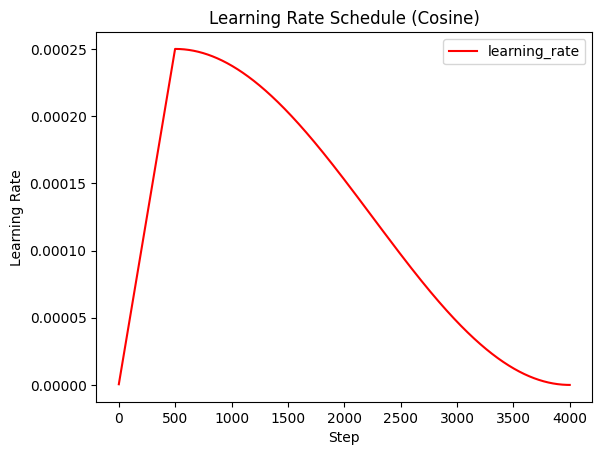

In [58]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

### 5-3. 모델을 실제로 빌드해보기

In [59]:
# 모델 생성을 위한 라이브러리 설치
!pip install torchinfo

In [60]:
# 모델 생성
from torchinfo import summary
# config 수정 예시 (모델 생성 전 실행)
config.n_vocab = 32007
config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            4,096,896
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

### 5-4. 학습 진행

#### 1) 학습설정

In [61]:
epochs = 10
batch_size = 64

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
criterion_mlm = nn.CrossEntropyLoss(ignore_index=-1)

train_steps: 17000


#### 2) 텐서변환 및 데이터로더 설정

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

# x가 텐서인지 확인하고, 텐서라면 cpu로 옮긴 뒤 numpy로 변환하거나 바로 텐서 처리를 합니다.
def to_tensor(x, device):
    if torch.is_tensor(x):
        return x.to(device) # 이미 텐서라면 장치만 이동
    else:
        return torch.tensor(np.array(x)).to(device) # 넘파이 배열이라면 텐서로 변환 후 이동

# 1. 학습 데이터 텐서 변환 및 DataLoader 생성
pre_train_inputs = [to_tensor(x, device) for x in pre_train_inputs]
pre_train_labels = [to_tensor(x, device) for x in pre_train_labels]
train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 2. 검증 데이터 텐서 변환 및 DataLoader 생성
val_enc_tokens = to_tensor(pre_val_inputs[0], device)
val_segments = to_tensor(pre_val_inputs[1], device)
val_labels_nsp = to_tensor(pre_val_labels[0], device)
val_labels_mlm = to_tensor(pre_val_labels[1], device)
val_dataset = TensorDataset(
    val_enc_tokens,
    val_segments,
    val_labels_nsp,
    val_labels_mlm
)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

pre_train_model.to(device)

history = {
    'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': [],
    'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': [] # 검증용 추가
}

#### 3) 학습루프

In [ ]:
for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        # Forward
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # Loss 계산
        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # Backward & Optimize
        total_loss_batch.backward()
        optimizer.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    # [VALIDATION 단계]
    pre_train_model.eval()
    val_total_loss, val_total_nsp_loss, val_total_mlm_loss = 0, 0, 0
    val_total_nsp_acc, val_total_mlm_acc = 0, 0

    with torch.no_grad():
        for batch in val_dataloader:
            enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

            logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

            labels_nsp_batch = labels_nsp_batch.long()
            labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
            loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

            val_total_loss += (loss_nsp + loss_mlm).item()
            val_total_nsp_loss += loss_nsp.item()
            val_total_mlm_loss += loss_mlm.item()

            val_total_nsp_acc += (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean().item()
            val_total_mlm_acc += (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean().item()

    # 검증 결과 저장
    history['val_nsp_loss'].append(val_total_nsp_loss / len(val_dataloader))
    history['val_mlm_loss'].append(val_total_mlm_loss / len(val_dataloader))
    history['val_nsp_acc'].append(val_total_nsp_acc / len(val_dataloader))
    history['val_mlm_acc'].append(val_total_mlm_acc / len(val_dataloader))

    # 에폭 결과 출력
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train -> Loss: {history['nsp_loss'][-1] + history['mlm_loss'][-1]:.4f}, NSP Acc: {history['nsp_acc'][-1]:.4f}, MLM Acc: {history['mlm_acc'][-1]:.4f}")
    print(f"  Val   -> Loss: {history['val_nsp_loss'][-1] + history['val_mlm_loss'][-1]:.4f}, NSP Acc: {history['val_nsp_acc'][-1]:.4f}, MLM Acc: {history['val_mlm_acc'][-1]:.4f}")
    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"{project_path}/work/bert_pre_train_epoch_{epoch+1}.pt")


Epoch 1/10
  Train -> Loss: 8.4318, NSP Acc: 0.6020, MLM Acc: 0.8279
  Val   -> Loss: 8.3034, NSP Acc: 0.6125, MLM Acc: 0.8720
Epoch 2/10
  Train -> Loss: 8.3052, NSP Acc: 0.6023, MLM Acc: 0.8719
  Val   -> Loss: 8.3023, NSP Acc: 0.6117, MLM Acc: 0.8720
Epoch 3/10
  Train -> Loss: 8.3037, NSP Acc: 0.6012, MLM Acc: 0.8719
  Val   -> Loss: 8.3022, NSP Acc: 0.5986, MLM Acc: 0.8720
Epoch 4/10
  Train -> Loss: 8.3030, NSP Acc: 0.6014, MLM Acc: 0.8719
  Val   -> Loss: 8.3014, NSP Acc: 0.6099, MLM Acc: 0.8720
Epoch 5/10
  Train -> Loss: 8.3024, NSP Acc: 0.6026, MLM Acc: 0.8719
  Val   -> Loss: 8.3008, NSP Acc: 0.6130, MLM Acc: 0.8720
Epoch 6/10
  Train -> Loss: 8.3017, NSP Acc: 0.6054, MLM Acc: 0.8719
  Val   -> Loss: 8.3030, NSP Acc: 0.5911, MLM Acc: 0.8720
Epoch 7/10
  Train -> Loss: 8.3006, NSP Acc: 0.6129, MLM Acc: 0.8719
  Val   -> Loss: 8.2993, NSP Acc: 0.6154, MLM Acc: 0.8720
Epoch 8/10
  Train -> Loss: 8.2986, NSP Acc: 0.6214, MLM Acc: 0.8719
  Val   -> Loss: 8.2978, NSP Acc: 0.6228, 

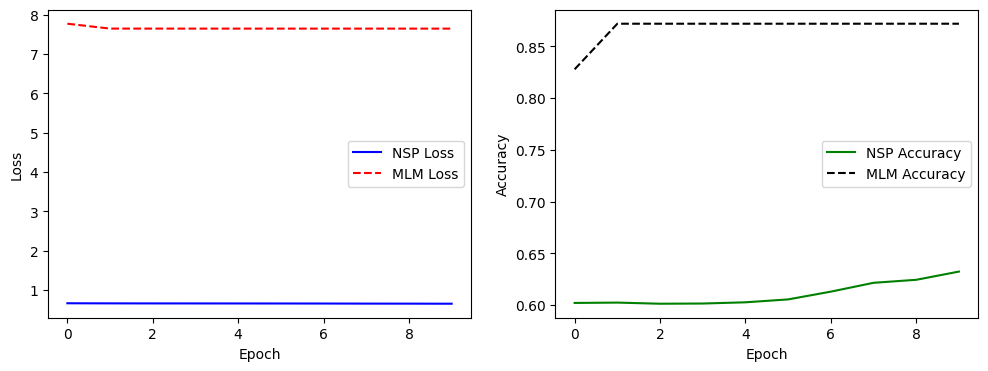

In [ ]:
import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


### [추가학습] (1) Epoch + 10 (총 20)

In [ ]:
# 1. 모델 가중치 불러오기
checkpoint_path = f"{project_path}/work/bert_pre_train_epoch_{epochs}.pt" # 마지막 에폭 파일명
pre_train_model.load_state_dict(torch.load(checkpoint_path))
print(f"가중치 로드 완료: {checkpoint_path}")

# 2. 추가 학습 설정
extra_epochs = 10  # 추가로 학습할 에폭 수
start_epoch = epochs # 이전 학습의 마지막 에폭 번호

가중치 로드 완료: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_epoch_10.pt


In [ ]:
# 3. 추가 학습 루프
for epoch in range(start_epoch, start_epoch + extra_epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        # Forward
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # Loss 계산
        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # Backward & Optimize
        total_loss_batch.backward()
        optimizer.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    # [VALIDATION 단계]
    pre_train_model.eval()
    val_total_loss, val_total_nsp_loss, val_total_mlm_loss = 0, 0, 0
    val_total_nsp_acc, val_total_mlm_acc = 0, 0

    with torch.no_grad():
        for batch in val_dataloader:
            enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

            logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

            labels_nsp_batch = labels_nsp_batch.long()
            labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
            loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

            val_total_loss += (loss_nsp + loss_mlm).item()
            val_total_nsp_loss += loss_nsp.item()
            val_total_mlm_loss += loss_mlm.item()

            val_total_nsp_acc += (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean().item()
            val_total_mlm_acc += (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean().item()

    # 검증 결과 저장
    history['val_nsp_loss'].append(val_total_nsp_loss / len(val_dataloader))
    history['val_mlm_loss'].append(val_total_mlm_loss / len(val_dataloader))
    history['val_nsp_acc'].append(val_total_nsp_acc / len(val_dataloader))
    history['val_mlm_acc'].append(val_total_mlm_acc / len(val_dataloader))

    # 에폭 결과 출력
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train -> Loss: {history['nsp_loss'][-1] + history['mlm_loss'][-1]:.4f}, NSP Acc: {history['nsp_acc'][-1]:.4f}, MLM Acc: {history['mlm_acc'][-1]:.4f}")
    print(f"  Val   -> Loss: {history['val_nsp_loss'][-1] + history['val_mlm_loss'][-1]:.4f}, NSP Acc: {history['val_nsp_acc'][-1]:.4f}, MLM Acc: {history['val_mlm_acc'][-1]:.4f}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"{project_path}/work/bert_pre_train_epoch_{epoch+1}.pt")


Epoch 11/10
  Train -> Loss: 8.2945, NSP Acc: 0.6367, MLM Acc: 0.8719
  Val   -> Loss: 8.2968, NSP Acc: 0.6254, MLM Acc: 0.8720
Epoch 12/10
  Train -> Loss: 8.2936, NSP Acc: 0.6407, MLM Acc: 0.8719
  Val   -> Loss: 8.2982, NSP Acc: 0.6215, MLM Acc: 0.8720
Epoch 13/10
  Train -> Loss: 8.2924, NSP Acc: 0.6434, MLM Acc: 0.8719
  Val   -> Loss: 8.2988, NSP Acc: 0.6207, MLM Acc: 0.8720
Epoch 14/10
  Train -> Loss: 8.2925, NSP Acc: 0.6435, MLM Acc: 0.8719
  Val   -> Loss: 8.2961, NSP Acc: 0.6257, MLM Acc: 0.8720
Epoch 15/10
  Train -> Loss: 8.2888, NSP Acc: 0.6509, MLM Acc: 0.8719
  Val   -> Loss: 8.2972, NSP Acc: 0.6263, MLM Acc: 0.8720
Epoch 16/10
  Train -> Loss: 8.2869, NSP Acc: 0.6560, MLM Acc: 0.8719
  Val   -> Loss: 8.2940, NSP Acc: 0.6316, MLM Acc: 0.8720
Epoch 17/10
  Train -> Loss: 8.2868, NSP Acc: 0.6584, MLM Acc: 0.8719
  Val   -> Loss: 8.2972, NSP Acc: 0.6242, MLM Acc: 0.8720
Epoch 18/10
  Train -> Loss: 8.2962, NSP Acc: 0.6352, MLM Acc: 0.8719
  Val   -> Loss: 8.2972, NSP Acc: 

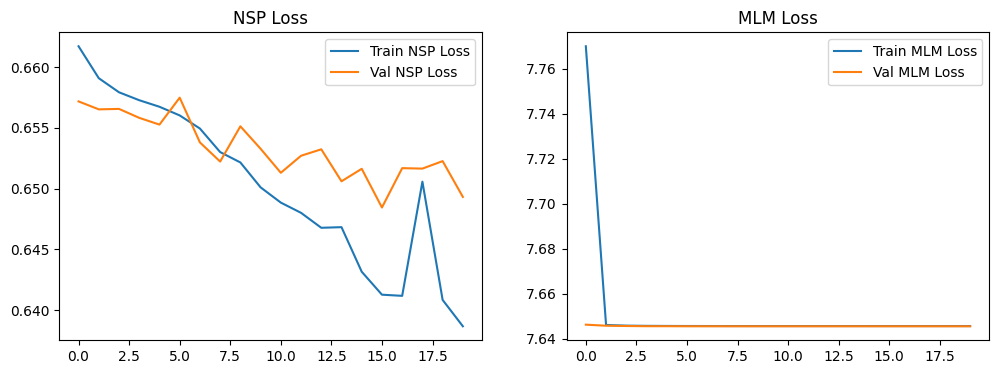

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], label='Train NSP Loss')
plt.plot(history['val_nsp_loss'], label='Val NSP Loss')
plt.legend()
plt.title('NSP Loss')

plt.subplot(1, 2, 2)
plt.plot(history['mlm_loss'], label='Train MLM Loss')
plt.plot(history['val_mlm_loss'], label='Val MLM Loss')
plt.legend()
plt.title('MLM Loss')
plt.show()


### [트래이너 클래스화]

#### 1) BERTTrainer Vr1

In [67]:
class BERTTrainer:
    def __init__(self, model, train_loader, val_loader, optimizer, loss_fns, config, device,history=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.loss_fn_nsp = loss_fns['nsp']
        self.loss_fn_mlm = loss_fns['mlm']
        self.config = config
        self.device = device
        # 만약 기존 history가 있으면 그것을 사용하고, 없으면 새로 만듭니다.
        if history is not None:
            self.history = history
        else:
            self.history = {
                'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': [],
                'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': []
            }

    def train(self, epochs, start_epoch=0, save_path="./"):
        for epoch in range(start_epoch, start_epoch + epochs):
            # --- [TRAIN 단계] ---
            self.model.train()
            train_results = self._run_epoch(self.train_loader, training=True)

            # 결과 저장 (Train)
            self.history['nsp_loss'].append(train_results['nsp_loss'])
            self.history['mlm_loss'].append(train_results['mlm_loss'])
            self.history['nsp_acc'].append(train_results['nsp_acc'])
            self.history['mlm_acc'].append(train_results['mlm_acc'])

            # --- [VALIDATION 단계] ---
            self.model.eval()
            with torch.no_grad():
                val_results = self._run_epoch(self.val_loader, training=False)

            # 결과 저장 (Val)
            self.history['val_nsp_loss'].append(val_results['nsp_loss'])
            self.history['val_mlm_loss'].append(val_results['mlm_loss'])
            self.history['val_nsp_acc'].append(val_results['nsp_acc'])
            self.history['val_mlm_acc'].append(val_results['mlm_acc'])

            # 에폭 결과 출력
            self._print_log(epoch, start_epoch + epochs)

            # 모델 저장
            save_file = f"{save_path}/bert_pre_train_epoch_{epoch+1}.pt"
            torch.save(self.model.state_dict(), save_file)

    def _run_epoch(self, dataloader, training=True):
        """한 에폭 동안 배치를 돌며 연산하는 내부 메서드"""
        total_nsp_loss, total_mlm_loss = 0, 0
        total_nsp_acc, total_mlm_acc = 0, 0

        for batch in dataloader:
            enc_tokens, segments, labels_nsp, labels_mlm = batch

            if training:
                self.optimizer.zero_grad()

            logits_nsp, logits_mlm = self.model(enc_tokens, segments)

            # 정답 데이터 정제
            labels_nsp = labels_nsp.long()
            labels_mlm = labels_mlm.clamp(0, self.config.n_vocab - 1).long()

            # Loss 계산
            loss_nsp = self.loss_fn_nsp(logits_nsp, labels_nsp)
            loss_mlm = self.loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm.view(-1))
            loss = loss_nsp + loss_mlm

            if training:
                loss.backward()
                self.optimizer.step()

            # 통계합산
            total_nsp_loss += loss_nsp.item()
            total_mlm_loss += loss_mlm.item()
            total_nsp_acc += (logits_nsp.argmax(dim=-1) == labels_nsp).float().mean().item()
            total_mlm_acc += (logits_mlm.argmax(dim=-1) == labels_mlm).float().mean().item()

        count = len(dataloader)
        return {
            'nsp_loss': total_nsp_loss / count,
            'mlm_loss': total_mlm_loss / count,
            'nsp_acc': total_nsp_acc / count,
            'mlm_acc': total_mlm_acc / count
        }

    def _print_log(self, epoch, total_epochs):
        print(f"Epoch {epoch+1}/{total_epochs}")
        print(f"  Train -> Loss: {self.history['nsp_loss'][-1] + self.history['mlm_loss'][-1]:.4f}, "
              f"NSP Acc: {self.history['nsp_acc'][-1]:.4f}, MLM Acc: {self.history['mlm_acc'][-1]:.4f}")
        print(f"  Val   -> Loss: {self.history['val_nsp_loss'][-1] + self.history['val_mlm_loss'][-1]:.4f}, "
              f"NSP Acc: {self.history['val_nsp_acc'][-1]:.4f}, MLM Acc: {self.history['val_mlm_acc'][-1]:.4f}")

#### 2) BERTTrainer Vr2 : 특수토큰 학습제외 + 히스토리 json으로 자동 저장

In [63]:
import torch
import os

class BERTTrainer:
    def __init__(self, model, train_loader, val_loader, optimizer, loss_fns, config, device, history=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.loss_fn_nsp = loss_fns['nsp']
        self.loss_fn_mlm = loss_fns['mlm']
        self.config = config
        self.device = device

        # 최적의 Loss를 추적하기 위한 변수 (초기값은 무한대)
        self.best_val_loss = float('inf')

        if history is not None:
            self.history = history
            # 기존 기록이 있다면 그 중 최소값을 best_val_loss로 설정
            if history['val_nsp_loss'] and history['val_mlm_loss']:
                self.best_val_loss = min([n + m for n, m in zip(history['val_nsp_loss'], history['val_mlm_loss'])])
        else:
            self.history = {
                'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': [],
                'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': []
            }

    def train(self, epochs, start_epoch=0, save_path="./"):
        if not os.path.exists(save_path):
            os.makedirs(save_path)

        # 히스토리 파일 경로 설정
        history_file = os.path.join(save_path, "history.json")

        for epoch in range(start_epoch, start_epoch + epochs):
            # --- [TRAIN 단계] ---
            self.model.train()
            train_results = self._run_epoch(self.train_loader, training=True)

            self.history['nsp_loss'].append(train_results['nsp_loss'])
            self.history['mlm_loss'].append(train_results['mlm_loss'])
            self.history['nsp_acc'].append(train_results['nsp_acc'])
            self.history['mlm_acc'].append(train_results['mlm_acc'])

            # --- [VALIDATION 단계] ---
            self.model.eval()
            with torch.no_grad():
                val_results = self._run_epoch(self.val_loader, training=False)

            self.history['val_nsp_loss'].append(val_results['nsp_loss'])
            self.history['val_mlm_loss'].append(val_results['mlm_loss']) # 수정된 key 사용
            self.history['val_nsp_acc'].append(val_results['nsp_acc'])
            self.history['val_mlm_acc'].append(val_results['mlm_acc'])

            # 현재 에폭의 전체 Validation Loss 계산
            current_val_loss = val_results['nsp_loss'] + val_results['mlm_loss']

            # 에폭 결과 출력
            self._print_log(epoch, start_epoch + epochs)

            # --- [1. 히스토리 파일 업데이트] ---
            # 매 에폭마다 호출되어 최신 정보를 저장합니다.
            with open(history_file, 'w') as f:
                json.dump(self.history, f, indent=4)
            print(f"  📊 History updated: {history_file}")

            # --- [2. 모델 체크포인트 저장 로직] ---
            # 1. 첫 번째 에폭일 때 저장
            # 2. 현재 Validation Loss가 역대 최저일 때 저장 (Best Model)
            is_best = current_val_loss < self.best_val_loss

            if (epoch == start_epoch) or is_best:
                if is_best:
                    self.best_val_loss = current_val_loss
                    print(f"✨ New Best Model Found! (Loss: {current_val_loss:.4f})")

                save_file = f"{save_path}/bert_pre_train_best.pt" if is_best else f"{save_path}/bert_pre_train_first.pt"
                # 에폭 정보를 파일명에 포함하고 싶다면 아래 주석 해제
                # save_file = f"{save_path}/bert_epoch_{epoch+1}_loss_{current_val_loss:.4f}.pt"

                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'loss': current_val_loss,
                    'history': self.history
                }, save_file)
                print(f"💾 Checkpoint saved: {save_file}")

    def _run_epoch(self, dataloader, training=True):
        total_nsp_loss, total_mlm_loss = 0, 0
        total_nsp_acc, total_mlm_acc = 0, 0

        for batch in dataloader:
            # 데이터를 장비(GPU/CPU)로 이동
            enc_tokens, segments, labels_nsp, labels_mlm = [x.to(self.device) for x in batch]

            # --- [안전장치 로직 시작] ---

            # [추가 안전장치] 입력 토큰이 사전 크기를 벗어나면 Embedding 층에서 에러가 납니다.
            # 0 ~ n_vocab-1 사이로 강제 제한합니다.
            enc_tokens = torch.clamp(enc_tokens.long(), min=0, max=self.config.n_vocab - 1)

            # [안전장치 1] NSP 라벨은 반드시 0 또는 1이어야 함 (0보다 작으면 0, 1보다 크면 1)
            labels_nsp = torch.clamp(labels_nsp.long(), min=0, max=1)

            # [안전장치 2] MLM 라벨이 n_vocab을 벗어나지 않도록 강제 제한
            # 단, 학습 제외용인 -1은 유지해야 하므로 마스크를 사용합니다.
            labels_mlm = labels_mlm.long()
            mask_for_clamp = (labels_mlm != -1)
            if mask_for_clamp.any(): # 마스킹된 데이터가 있는 경우에만 실행
                labels_mlm[mask_for_clamp] = torch.clamp(
                    labels_mlm[mask_for_clamp], min=0, max=self.config.n_vocab - 1
                )

            # --- [안전장치 로직 종료] ---

            if training:
                self.optimizer.zero_grad()

            # 2. 모델 예측 (Forward Pass)
            logits_nsp, logits_mlm = self.model(enc_tokens, segments)

            # 3. NSP Loss 계산
            loss_nsp = self.loss_fn_nsp(logits_nsp, labels_nsp.long())

            # 4. MLM Loss 계산 (특수 토큰 제외 설정)
            # labels_mlm에서 마스킹되지 않은 부분(보통 -1 또는 0으로 설정된 부분)은
            # loss_fn_mlm 정의 시 ignore_index로 설정되어 있어야 합니다.
            loss_mlm = self.loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm.view(-1).long())

            loss = loss_nsp + loss_mlm

            # 5. 역전파 및 최적화
            if training:
                loss.backward()
                self.optimizer.step()

            # 6. 통계 합산 및 정확도 계산
            total_nsp_loss += loss_nsp.item()
            total_mlm_loss += loss_mlm.item()

            # NSP 정확도
            total_nsp_acc += (logits_nsp.argmax(dim=-1) == labels_nsp).float().mean().item()

            # MLM 정확도 계산 시에도 마스킹된 부분만 계산하도록 필터링
            mask = (labels_mlm != -1) # -1은 학습에서 제외할 토큰의 index (설정에 따라 변경 가능)
            if mask.sum() > 0:
                correct = (logits_mlm.argmax(dim=-1) == labels_mlm) & mask
                total_mlm_acc += correct.sum().item() / mask.sum().item()

        count = len(dataloader)
        return {
            'nsp_loss': total_nsp_loss / count,
            'mlm_loss': total_mlm_loss / count,
            'nsp_acc': total_nsp_acc / count,
            'mlm_acc': total_mlm_acc / count
        }
    # 누락되었던 출력 메서드
    def _print_log(self, epoch, total_epochs):
        print(f"Epoch {epoch+1}/{total_epochs}")
        # Train 결과 출력
        train_loss = self.history['nsp_loss'][-1] + self.history['mlm_loss'][-1]
        print(f"  Train -> Loss: {train_loss:.4f}, NSP Acc: {self.history['nsp_acc'][-1]:.4f}, MLM Acc: {self.history['mlm_acc'][-1]:.4f}")
        # Val 결과 출력
        val_loss = self.history['val_nsp_loss'][-1] + self.history['val_mlm_loss'][-1]
        print(f"  Val   -> Loss: {val_loss:.4f}, NSP Acc: {self.history['val_nsp_acc'][-1]:.4f}, MLM Acc: {self.history['val_mlm_acc'][-1]:.4f}")

#### 3) BERTTrainer Vr3 : 통계 합산 및 정확도 계산 개선 + AdamW 옵티마이저로 교체

In [68]:
from transformers import get_linear_schedule_with_warmup
import torch.optim as optim

# 1. 학습률 설정 (1e-4보다 조금 낮은 5e-5 권장)
learning_rate = 5e-5
weight_decay = 0.01

# 2. AdamW 옵티마이저 설정
optimizer = optim.AdamW(
    pre_train_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# 3. 스케줄러 설정을 위한 총 학습 스텝 계산
epochs = 10
total_steps = len(train_dataloader) * epochs
warmup_steps = int(total_steps * 0.1) # 전체의 10%를 웜업에 사용

# 4. 선형 웜업 스케줄러 생성
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

In [82]:
import torch
import os

class BERTTrainer:
    def __init__(self, model, train_loader, val_loader, optimizer, loss_fns, config, device, history=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.loss_fn_nsp = loss_fns['nsp']
        self.loss_fn_mlm = loss_fns['mlm']
        self.config = config
        self.device = device

        # 최적의 Loss를 추적하기 위한 변수 (초기값은 무한대)
        self.best_val_loss = float('inf')

        if history is not None:
            self.history = history
            # 기존 기록이 있다면 그 중 최소값을 best_val_loss로 설정
            if history['val_nsp_loss'] and history['val_mlm_loss']:
                self.best_val_loss = min([n + m for n, m in zip(history['val_nsp_loss'], history['val_mlm_loss'])])
        else:
            self.history = {
                'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': [],
                'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': []
            }

    def train(self, epochs, start_epoch=0, save_path="./"):
        if not os.path.exists(save_path):
            os.makedirs(save_path)

        # 히스토리 파일 경로 설정
        history_file = os.path.join(save_path, "history.json")

        for epoch in range(start_epoch, start_epoch + epochs):
            # --- [TRAIN 단계] ---
            self.model.train()
            train_results = self._run_epoch(self.train_loader, training=True)

            self.history['nsp_loss'].append(train_results['nsp_loss'])
            self.history['mlm_loss'].append(train_results['mlm_loss'])
            self.history['nsp_acc'].append(train_results['nsp_acc'])
            self.history['mlm_acc'].append(train_results['mlm_acc'])

            # --- [VALIDATION 단계] ---
            self.model.eval()
            with torch.no_grad():
                val_results = self._run_epoch(self.val_loader, training=False)

            self.history['val_nsp_loss'].append(val_results['nsp_loss'])
            self.history['val_mlm_loss'].append(val_results['mlm_loss']) # 수정된 key 사용
            self.history['val_nsp_acc'].append(val_results['nsp_acc'])
            self.history['val_mlm_acc'].append(val_results['mlm_acc'])

            # 현재 에폭의 전체 Validation Loss 계산
            current_val_loss = val_results['nsp_loss'] + val_results['mlm_loss']

            # 에폭 결과 출력
            self._print_log(epoch, start_epoch + epochs)

            # --- [1. 히스토리 파일 업데이트] ---
            # 매 에폭마다 호출되어 최신 정보를 저장합니다.
            with open(history_file, 'w') as f:
                json.dump(self.history, f, indent=4)
            print(f"  📊 History updated: {history_file}")

            # --- [2. 모델 체크포인트 저장 로직] ---
            # 1. 첫 번째 에폭일 때 저장
            # 2. 현재 Validation Loss가 역대 최저일 때 저장 (Best Model)
            is_best = current_val_loss < self.best_val_loss

            if (epoch == start_epoch) or is_best:
                if is_best:
                    self.best_val_loss = current_val_loss
                    print(f"✨ New Best Model Found! (Loss: {current_val_loss:.4f})")

                save_file = f"{save_path}/bert_pre_train_best.pt" if is_best else f"{save_path}/bert_pre_train_first.pt"
                # 에폭 정보를 파일명에 포함하고 싶다면 아래 주석 해제
                # save_file = f"{save_path}/bert_epoch_{epoch+1}_loss_{current_val_loss:.4f}.pt"

                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'loss': current_val_loss,
                    'history': self.history
                }, save_file)
                print(f"💾 Checkpoint saved: {save_file}")

    def _run_epoch(self, dataloader, training=True):
        total_nsp_loss, total_mlm_loss = 0, 0
        total_nsp_acc, total_mlm_acc = 0, 0

        for batch in dataloader:
            # 데이터를 장비(GPU/CPU)로 이동
            enc_tokens, segments, labels_nsp, labels_mlm = [x.to(self.device) for x in batch]

            # --- [안전장치 로직 시작] ---

            # [추가 안전장치] 입력 토큰이 사전 크기를 벗어나면 Embedding 층에서 에러가 납니다.
            # 0 ~ n_vocab-1 사이로 강제 제한합니다.
            enc_tokens = torch.clamp(enc_tokens.long(), min=0, max=self.config.n_vocab - 1)

            # [안전장치 1] NSP 라벨은 반드시 0 또는 1이어야 함 (0보다 작으면 0, 1보다 크면 1)
            labels_nsp = torch.clamp(labels_nsp.long(), min=0, max=1)

            # [안전장치 2] MLM 라벨이 n_vocab을 벗어나지 않도록 강제 제한
            # 단, 학습 제외용인 -1은 유지해야 하므로 마스크를 사용합니다.
            labels_mlm = labels_mlm.long()
            mask_for_clamp = (labels_mlm != -1)
            if mask_for_clamp.any(): # 마스킹된 데이터가 있는 경우에만 실행
                labels_mlm[mask_for_clamp] = torch.clamp(
                    labels_mlm[mask_for_clamp], min=0, max=self.config.n_vocab - 1
                )

            # --- [안전장치 로직 종료] ---

            if training:
                self.optimizer.zero_grad()

            # 2. 모델 예측 (Forward Pass)
            logits_nsp, logits_mlm = self.model(enc_tokens, segments)

            # 3. NSP Loss 계산
            loss_nsp = self.loss_fn_nsp(logits_nsp, labels_nsp.long())

            # 4. MLM Loss 계산 (특수 토큰 제외 설정)
            # labels_mlm에서 마스킹되지 않은 부분(보통 -1 또는 0으로 설정된 부분)은
            # loss_fn_mlm 정의 시 ignore_index로 설정되어 있어야 합니다.
            loss_mlm = self.loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm.view(-1).long())

            loss = loss_nsp + loss_mlm

            # 5. 역전파 및 최적화
            if training:
                loss.backward()
                self.optimizer.step()

            # 6. 통계 합산 및 정확도 계산
            # 1) NSP 통계
            total_nsp_loss += loss_nsp.item()
            # NSP는 모든 배치가 동일한 개수(Batch Size)를 가지므로 단순 평균이 가능합니다.
            total_nsp_acc += (logits_nsp.argmax(dim=-1) == labels_nsp).float().mean().item()
            total_nsp_loss += loss_nsp.item()
            # 2) MLM 통계
            total_mlm_loss += loss_mlm.item()

            # MLM 정확도 계산 시에도 마스킹된 부분만 계산하도록 필터링
            mask = (labels_mlm != -1) # -1은 학습에서 제외할 토큰의 index (설정에 따라 변경 가능)
            mask_count = mask.sum().item()
            if mask_count > 0:
              # 모델의 예측값 중 가장 확률이 높은 인덱스 추출
              preds = logits_mlm.argmax(dim=-1)

              # 마스킹된 위치에서 예측이 정답과 일치하는지 확인 (True/False)
              # .logical_and 대신 & 연산자를 사용하며, 반드시 동일한 장치(device)에서 연산됨을 보장합니다.
              correct_mask = (preds == labels_mlm) & mask

              # 이 배치의 진짜 MLM 정확도 (마스킹된 것 중 맞춘 것의 비율)
              batch_mlm_acc = correct_mask.sum().item() / mask_count
              total_mlm_acc += batch_mlm_acc
            else:
                # 만약 배치에 마스크가 하나도 없다면 정확도 합산에서 제외 (분모 계산 시 주의)
                pass

        count = len(dataloader)
        # 1. NSP 지표는 배치 수로 나누어도 무방합니다 (모든 문장에 CLS가 있으므로)
        avg_nsp_loss = total_nsp_loss / count
        avg_nsp_acc = total_nsp_acc / count

        # 2. MLM Loss는 보통 토큰 단위가 아닌 배치 단위 평균으로 계산하므로 유지
        avg_mlm_loss = total_mlm_loss / count

        # 3. [중요] MLM 정확도는 실제 마스킹된 토큰 전체 중 맞춘 개수로 계산 (Micro-Average)
        # 만약 루프에서 total_mlm_acc += batch_acc 방식을 썼다면,
        # 마스크가 존재했던 배치 수(mlm_step_count)로 나누어야 합니다.

        # 예시: 배치별 정확도를 더해왔을 경우
        # if mlm_step_count > 0:
        #     final_mlm_acc = total_mlm_acc / mlm_step_count
        # else:
        #     final_mlm_acc = 0.0
        return {
            'nsp_loss': avg_nsp_loss,
            'mlm_loss': avg_mlm_loss,
            'nsp_acc': avg_nsp_acc,
            'mlm_acc': total_mlm_acc / count
        }
    # 누락되었던 출력 메서드
    def _print_log(self, epoch, total_epochs):
        print(f"Epoch {epoch+1}/{total_epochs}")
        # Train 결과 출력
        train_loss = self.history['nsp_loss'][-1] + self.history['mlm_loss'][-1]
        print(f"  Train -> Loss: {train_loss:.4f}, NSP Acc: {self.history['nsp_acc'][-1]:.4f}, MLM Acc: {self.history['mlm_acc'][-1]:.4f}")
        # Val 결과 출력
        val_loss = self.history['val_nsp_loss'][-1] + self.history['val_mlm_loss'][-1]
        print(f"  Val   -> Loss: {val_loss:.4f}, NSP Acc: {self.history['val_nsp_acc'][-1]:.4f}, MLM Acc: {self.history['val_mlm_acc'][-1]:.4f}")

#### 4) BERTTrainer Vr4: Learning Rate 수정

In [81]:
from transformers import get_linear_schedule_with_warmup
import torch.optim as optim

# 1. 학습률 설정 (1e-4보다 조금 낮은 5e-5 권장)
learning_rate = 3e-5
weight_decay = 0.01

# 2. AdamW 옵티마이저 설정
optimizer = optim.AdamW(
    pre_train_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# 3. 스케줄러 설정을 위한 총 학습 스텝 계산
epochs = 10
total_steps = len(train_dataloader) * epochs
warmup_steps = int(total_steps * 0.1) # 전체의 10%를 웜업에 사용

# 4. 선형 웜업 스케줄러 생성
# 스케줄러에도 동일한 max_lr 적용
scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=total_steps,
    warmup_steps=warmup_steps,
    max_lr=learning_rate # 여기도 3e-5로 맞춰주세요
)

### [시각화 코드 클래스화]

In [64]:
import matplotlib.pyplot as plt
import numpy as np

class BERTVisualizer:
    def __init__(self, history):
        self.history = history

    def plot_loss(self):
        plt.figure(figsize=(15, 5))

        # 1. NSP Loss 그래프
        plt.subplot(1, 2, 1)
        self._draw_loss_plot(
            self.history['nsp_loss'],
            self.history['val_nsp_loss'],
            'NSP Loss'
        )

        # 2. MLM Loss 그래프
        plt.subplot(1, 2, 2)
        self._draw_loss_plot(
            self.history['mlm_loss'],
            self.history['val_mlm_loss'],
            'MLM Loss'
        )

        plt.tight_layout()
        plt.show()

    def _draw_loss_plot(self, train_loss, val_loss, title):
        epochs = range(1, len(train_loss) + 1)

        # 기본 선 그래프
        plt.plot(epochs, train_loss, 'b--', label=f'Train {title}', alpha=0.6)
        plt.plot(epochs, val_loss, 'r-', label=f'Val {title}', linewidth=2)

        # 최저점 찾기 (Validation Loss 기준)
        min_val_loss = min(val_loss)
        min_epoch = val_loss.index(min_val_loss) + 1

        # 최저점에 별 표시 (★)
        plt.scatter(min_epoch, min_val_loss, color='red', marker='*', s=200,
                    label=f'Best (Ep:{min_epoch})', zorder=5)

        # 주석 추가 (숫자 표시)
        plt.annotate(f'{min_val_loss:.4f}',
                     xy=(min_epoch, min_val_loss),
                     xytext=(min_epoch, min_val_loss + (max(val_loss)-min_val_loss)*0.1),
                     ha='center', fontsize=10, color='red',
                     arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))

        plt.title(title, fontsize=14)
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend()

### [추가학습] (1) Epoch + 10 에서 다시 + 10 (총 30)

In [ ]:
# 1. 모델 가중치 로드 (가장 최근 에폭 파일)
last_epoch = 20 # 만약 10에폭까지 학습했다면
last_checkpoint = f"{project_path}/work/bert_pre_train_epoch_{last_epoch}.pt" # 마지막 에폭 파일명
pre_train_model.load_state_dict(torch.load(last_checkpoint))

# 2. 객체 생성 (기존 history 주입)
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    history=history # <--- 여기서 기존 히스토리를 넣어줍니다!
)

# 3. 이어서 학습 (start_epoch를 기존 완료 지점으로 설정)
trainer.train(epochs=10, start_epoch=last_epoch, save_path=f"{project_path}/work")

Epoch 21/30
  Train -> Loss: 8.2845, NSP Acc: 0.6639, MLM Acc: 0.8719
  Val   -> Loss: 8.2929, NSP Acc: 0.6310, MLM Acc: 0.8720
Epoch 22/30
  Train -> Loss: 8.2833, NSP Acc: 0.6668, MLM Acc: 0.8719
  Val   -> Loss: 8.2944, NSP Acc: 0.6293, MLM Acc: 0.8720
Epoch 23/30
  Train -> Loss: 8.2818, NSP Acc: 0.6709, MLM Acc: 0.8719
  Val   -> Loss: 8.2978, NSP Acc: 0.6282, MLM Acc: 0.8720
Epoch 24/30
  Train -> Loss: 8.2808, NSP Acc: 0.6735, MLM Acc: 0.8719
  Val   -> Loss: 8.2970, NSP Acc: 0.6322, MLM Acc: 0.8720
Epoch 25/30
  Train -> Loss: 8.2796, NSP Acc: 0.6769, MLM Acc: 0.8719
  Val   -> Loss: 8.2951, NSP Acc: 0.6351, MLM Acc: 0.8720
Epoch 26/30
  Train -> Loss: 8.2802, NSP Acc: 0.6754, MLM Acc: 0.8719
  Val   -> Loss: 8.2958, NSP Acc: 0.6390, MLM Acc: 0.8720
Epoch 27/30
  Train -> Loss: 8.2780, NSP Acc: 0.6803, MLM Acc: 0.8719
  Val   -> Loss: 8.2951, NSP Acc: 0.6383, MLM Acc: 0.8720
Epoch 28/30
  Train -> Loss: 8.2770, NSP Acc: 0.6828, MLM Acc: 0.8719
  Val   -> Loss: 8.2950, NSP Acc: 

In [65]:
history_file =f"{project_path}/work/history.json"
with open(history_file, 'w') as f:
    json.dump(history, f, indent=4)
print(f"  History saved to {history_file}")

  History saved to /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json


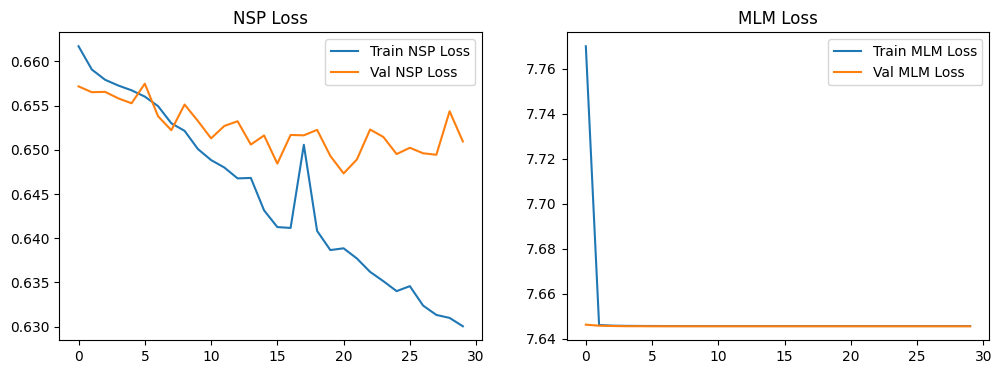

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], label='Train NSP Loss')
plt.plot(history['val_nsp_loss'], label='Val NSP Loss')
plt.legend()
plt.title('NSP Loss')

plt.subplot(1, 2, 2)
plt.plot(history['mlm_loss'], label='Train MLM Loss')
plt.plot(history['val_mlm_loss'], label='Val MLM Loss')
plt.legend()
plt.title('MLM Loss')
plt.show()


### [새로학습] (1) 특수토큰은 마스크 처리 하지 않고, 학습하지 않게 설정 후 새로 학습

#### 일단 오류부터 해결...!

In [125]:
device = 'cpu'

In [126]:
import numpy as np
import torch

def check_data(data, name, max_val):
    # 리스트나 튜플일 경우 넘파이 배열로 변환하여 확인
    arr = np.array(data)
    min_idx = arr.min()
    max_idx = arr.max()
    print(f"[{name}] 최소 인덱스: {min_idx}, 최대 인덱스: {max_idx}")

    if max_idx >= max_val:
        print(f"❌ 에러 발생 가능성: {name}에 단어 사전 크기({max_val})를 벗어나는 값이 있습니다!")
    if min_idx < -1: # 보통 -1은 ignore_index로 쓰입니다.
        print(f"❌ 에러 발생 가능성: {name}에 정의되지 않은 음수 값이 있습니다!")

# 1. 입력 토큰 확인 (0 ~ 32006 사이여야 함)
check_data(pre_val_inputs[0], "Validation Inputs", 32007)

# 2. MLM 라벨 확인 (0 ~ 32006 사이이거나, 학습 제외용 -1이어야 함)
check_data(pre_val_labels[1], "Validation MLM Labels", 32007)

[Validation Inputs] 최소 인덱스: 0, 최대 인덱스: 32002
[Validation MLM Labels] 최소 인덱스: 0, 최대 인덱스: 31988


In [129]:
# 모델 파일 경로 (예: ko_32000.model)
spp = spm.SentencePieceProcessor()
spp.load(f"{data_path}/ko_32000.model")

# 로드한 spp 모델의 전체 단어 수 확인
print(f"실제 사전 크기: {len(spp)}")

# 마지막 단어 5개만 확인해보기
for i in range(len(spp)-5, len(spp)):
    print(f"Index {i}: {spp.id_to_piece(i)}")

실제 사전 크기: 32007
Index 32002: 垈
Index 32003: 尸
Index 32004: 慚
Index 32005: 楠
Index 32006: 絹


In [130]:
# NSP 라벨은 반드시 0 또는 1이어야 합니다.
arr_nsp = np.array(pre_val_labels[0])
print(f"[NSP Labels] 고유값 목록: {np.unique(arr_nsp)}")

if not np.all((arr_nsp == 0) | (arr_nsp == 1)):
    print("❌ 에러: NSP 라벨에 0이나 1이 아닌 값이 섞여 있습니다!")

[NSP Labels] 고유값 목록: [0 1]


In [132]:
# 모델 생성 시 사용한 config 값을 확인해 보세요.
print(f"현재 모델의 n_vocab 설정값: {config.n_vocab}")

if config.n_vocab < 32007:
    print(f"❌ 위험: 데이터에는 32002번 단어가 있는데, 모델은 {config.n_vocab}번까지만 이해할 수 있습니다.")

현재 모델의 n_vocab 설정값: 32007


#### 진짜 새로 학습

In [ ]:
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
# 새로 시작할 때
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device
)

# 3. 이어서 학습 (start_epoch를 기존 완료 지점으로 설정)
trainer.train(epochs=10, save_path=f"{project_path}/work")

Epoch 1/10
  Train -> Loss: 10.1522, NSP Acc: 0.6297, MLM Acc: 0.8719
  Val   -> Loss: 10.1547, NSP Acc: 0.6256, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
✨ New Best Model Found! (Loss: 10.1547)
💾 Checkpoint saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_best.pt
Epoch 2/10
  Train -> Loss: 10.1449, NSP Acc: 0.6512, MLM Acc: 0.8719
  Val   -> Loss: 10.1573, NSP Acc: 0.6223, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
Epoch 3/10
  Train -> Loss: 10.1386, NSP Acc: 0.6687, MLM Acc: 0.8719
  Val   -> Loss: 10.1491, NSP Acc: 0.6345, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
✨ New Best Model Found! (Loss: 10.1491)
💾 Checkpoint saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_best.pt
Epoch 4/10
  Train -> Loss: 10.1335

In [66]:
# 1. 모델 가중치 불러오기
checkpoint_path = f"{project_path}/work/bert_pre_train_best.pt" # 마지막 에폭 파일명
# Load the entire checkpoint dictionary
checkpoint = torch.load(checkpoint_path, map_location=device)
# Extract only the model's state_dict
pre_train_model.load_state_dict(checkpoint['model_state_dict'])
print(f"가중치 로드 완료: {checkpoint_path}")

# 2. 추가 학습 설정
extra_epochs = 5  # 추가로 학습할 에폭 수
start_epoch = 5 # 이전 학습의 마지막 에폭 번호

가중치 로드 완료: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_best.pt


In [67]:
# 1. 모델 가중치 로드 (가장 최근 에폭 파일)
last_epoch = 5 # 만약 5에폭까지 학습했다면

# 2. 객체 생성 (기존 history 주입)
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    history=history # <--- 여기서 기존 히스토리를 넣어줍니다!
)

# 3. 이어서 학습 (start_epoch를 기존 완료 지점으로 설정)
trainer.train(epochs=10, start_epoch=last_epoch, save_path=f"{project_path}/work")

Epoch 6/15
  Train -> Loss: 10.1323, NSP Acc: 0.6849, MLM Acc: 0.8719
  Val   -> Loss: 10.1497, NSP Acc: 0.6367, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
✨ New Best Model Found! (Loss: 10.1497)
💾 Checkpoint saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_best.pt
Epoch 7/15
  Train -> Loss: 10.1276, NSP Acc: 0.6955, MLM Acc: 0.8719
  Val   -> Loss: 10.1553, NSP Acc: 0.6322, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
Epoch 8/15
  Train -> Loss: 10.1233, NSP Acc: 0.7056, MLM Acc: 0.8719
  Val   -> Loss: 10.1541, NSP Acc: 0.6356, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
Epoch 9/15
  Train -> Loss: 10.1180, NSP Acc: 0.7179, MLM Acc: 0.8719
  Val   -> Loss: 10.1545, NSP Acc: 0.6336, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study

In [70]:
# 1. 모델 가중치 불러오기
checkpoint_path = f"{project_path}/work/bert_pre_train_best.pt" # 마지막 에폭 파일명
# Load the entire checkpoint dictionary
checkpoint = torch.load(checkpoint_path, map_location=device)
# Extract only the model's state_dict
pre_train_model.load_state_dict(checkpoint['model_state_dict'])
print(f"가중치 로드 완료: {checkpoint_path}")
# 2. 옵티마이저 상태 로드 (추가됨)
# 주의: optimizer가 먼저 정의되어 있어야 합니다.
if 'optimizer_state_dict' in checkpoint:
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print("옵티마이저 상태 로드 완료")

# 3. 객체 생성 (기존 history 주입)
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    history=history # <--- 여기서 기존 히스토리를 넣어줍니다!
)

# 4. 이어서 학습 (start_epoch를 기존 완료 지점으로 설정)
trainer.train(epochs=2, start_epoch=15, save_path=f"{project_path}/work")

가중치 로드 완료: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_best.pt
옵티마이저 상태 로드 완료
Epoch 16/17
  Train -> Loss: 10.7544, NSP Acc: 0.6945, MLM Acc: 0.8719
  Val   -> Loss: 10.8078, NSP Acc: 0.6297, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
💾 Checkpoint saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_first.pt
Epoch 17/17
  Train -> Loss: 10.7456, NSP Acc: 0.7053, MLM Acc: 0.8719
  Val   -> Loss: 10.8078, NSP Acc: 0.6364, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json


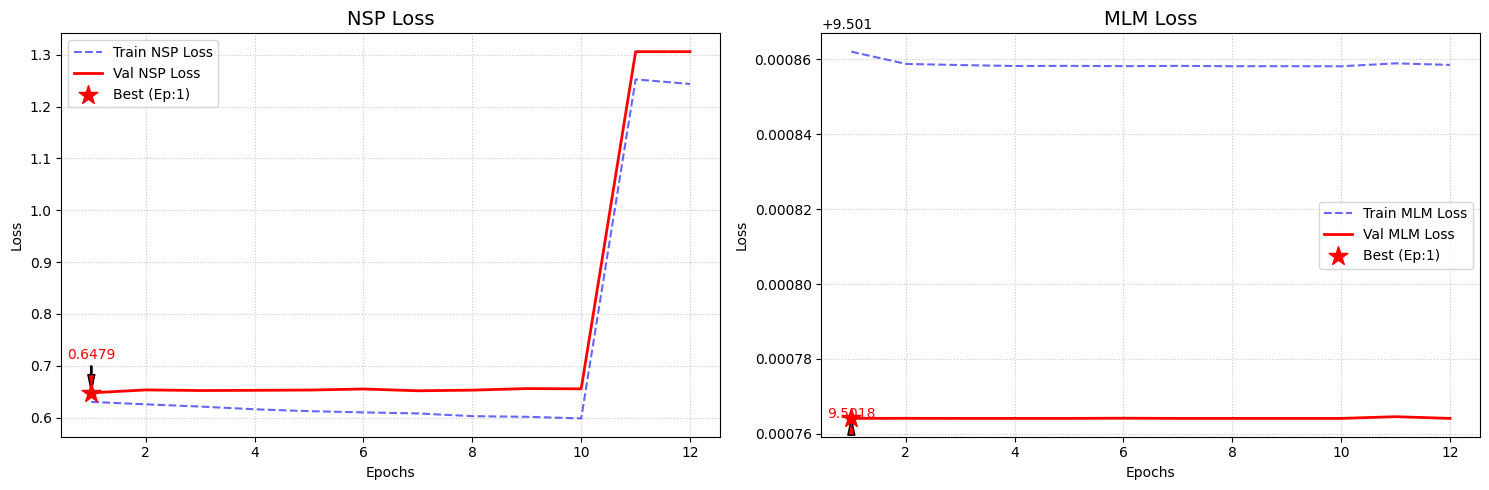

In [75]:
# 1. 시각화 객체 생성 (trainer 내부에 저장된 history 전달)
visualizer = BERTVisualizer(trainer.history)

# 2. 그래프 출력
visualizer.plot_loss()

### 다시 새로학습

In [83]:
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
# 새로 시작할 때
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device
)

# 3. 이어서 학습 (start_epoch를 기존 완료 지점으로 설정)
trainer.train(epochs=10, save_path=f"{project_path}/work")

Epoch 1/10
  Train -> Loss: 10.7448, NSP Acc: 0.7070, MLM Acc: 0.8719
  Val   -> Loss: 10.8012, NSP Acc: 0.6361, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
✨ New Best Model Found! (Loss: 10.8012)
💾 Checkpoint saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_best.pt
Epoch 2/10
  Train -> Loss: 10.7384, NSP Acc: 0.7134, MLM Acc: 0.8719
  Val   -> Loss: 10.8026, NSP Acc: 0.6338, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
Epoch 3/10
  Train -> Loss: 10.7344, NSP Acc: 0.7174, MLM Acc: 0.8719
  Val   -> Loss: 10.8042, NSP Acc: 0.6330, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
Epoch 4/10
  Train -> Loss: 10.7313, NSP Acc: 0.7201, MLM Acc: 0.8719
  Val   -> Loss: 10.8062, NSP Acc: 0.6362, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study

In [ ]:
# 1. 시각화 객체 생성 (trainer 내부에 저장된 history 전달)
visualizer = BERTVisualizer(trainer.history)

# 2. 그래프 출력
visualizer.plot_loss()

## 6. 챗봇

#### 1) BERT용 챗봇 코드

In [72]:
import sys

# 만약 로컬 환경에서 실제 ESC 키를 감지하고 싶다면 아래 라이브러리가 필요합니다.
# !pip install keyboard
try:
    # import keyboard # Removed keyboard import
    keyboard = None # Set keyboard to None to disable its usage
except ImportError:
    keyboard = None

In [73]:
def start_chatting_bert(model, tokenizer, device, max_seq_len=128):
    model.eval()

    print("="*50)
    print("    BERT 단어 예측 테스트 (언더바 버전)")
    print("    예: '나는 오늘 __ 를 먹었다' - '_(언더바)'2개+' (띄어쓰기)'")
    print("    (종료하려면 'esc'를 입력하세요)")
    print("="*50)

    while True:
        user_input = input("\n나: ").strip()
        if user_input.lower() == 'esc': break

        # 1. 사용자가 입력한 '__'를 '[MASK]'로 치환
        # 이렇게 하면 입력할 때는 편하고, 모델은 원래대로 [MASK]를 인식합니다.
        processed_input = user_input.replace("__", "[MASK]")

        if "[MASK]" not in processed_input:
            print("챗봇: 문장에 '__'를 포함해 주세요! (예: 하늘이 __다)")
            continue

        try:
            # 2. 토큰화
            tokens = tokenizer.encode_as_pieces(processed_input)
            tokens = ["[CLS]"] + tokens + ["[SEP]"]

            # 3. [MASK] 토큰 위치 찾기
            if "[MASK]" not in tokens:
                print("챗봇: 토큰화 과정에서 마스크가 인식되지 않았습니다. '__' 앞뒤에 공백을 주어보세요.")
                continue
            mask_idx = tokens.index("[MASK]")

            # 4. ID 변환 및 텐서 생성
            input_ids = [tokenizer.piece_to_id(p) for p in tokens]
            segment_ids = [0] * len(input_ids)

            input_ids = torch.tensor([input_ids]).to(device)
            segment_ids = torch.tensor([segment_ids]).to(device)

            with torch.no_grad():
                _, logits_lm = model(input_ids, segment_ids)
                mask_logits = logits_lm[0, mask_idx]
                probs = torch.softmax(mask_logits, dim=-1)
                topk_prob, topk_indices = torch.topk(probs, 5)

            print("챗봇 (예측):")
            for i, (idx, prob) in enumerate(zip(topk_indices, topk_prob)):
                word = tokenizer.id_to_piece(int(idx))
                print(f"  {i+1}순위: {word} ({prob.item()*100:.2f}%)")

        except Exception as e:
            print(f"에러가 발생했어요: {e}")

#### 2) 런타임이 끊긴 경우 저장된 모델 불러오기

* 사전에 드라이브 부터 연결

In [68]:
import os

# --- 설정 (사용자 환경에 맞게 수정) ---
save_dir = os.path.join(project_path, "work")
history_path = os.path.join(project_path, "history.json")
last_epoch = 0

# 1. 이전 상태 복구 (모델 & 히스토리)
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    last_epoch = len(history['nsp_loss'])

    # 마지막 저장된 모델 로드
    model_file = os.path.join(save_dir, f"bert_pre_train_epoch_{last_epoch}.pt")
    if os.path.exists(model_file):
        pre_train_model.load_state_dict(torch.load(model_file, map_location=device))
        print(f"✅ {last_epoch} 에폭 모델 가중치를 성공적으로 로드했습니다.")
else:
    history = None
    print("🆕 기존 기록이 없어 처음부터 시작합니다.")

# 2. Trainer 객체 생성
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    history=history
)

# 3. 추가 학습 실행 (예: 5에폭 더 학습)
# 학습이 이미 충분하다면 이 줄을 주석 처리하고 바로 챗봇으로 넘어가세요.
# trainer.train(epochs=5, start_epoch=last_epoch, save_path=save_dir)

🆕 기존 기록이 없어 처음부터 시작합니다.


#### 3) 챗봇 실행

In [69]:
# 모델 파일 경로 (예: ko_32000.model)
spp = spm.SentencePieceProcessor()
spp.load(f"{data_path}/ko_32000.model")

# 위에서 정의한 start_chatting_bert 함수를 호출합니다.
print("\n" + "!"*30)
print("학습된 BERT 모델로 단어 예측 테스트를 시작합니다.")
print("!"*30)

# 이제 챗봇 함수에 이 'spp'를 넣어주세요
start_chatting_bert(pre_train_model, spp, device)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
학습된 BERT 모델로 단어 예측 테스트를 시작합니다.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    BERT 단어 예측 테스트 (언더바 버전)
    예: '나는 오늘 __ 를 먹었다' - '_(언더바)'2개+' (띄어쓰기)'
    (종료하려면 'esc'를 입력하세요)

나: 오늘 날씨가 너무 __ 좋아서 산책을 갔다.
챗봇 (예측):
  1순위: ▁기억 (0.02%)
  2순위: ▁잭 (0.02%)
  3순위: 과에 (0.02%)
  4순위: 니다 (0.02%)
  5순위: ▁경향 (0.02%)

나: 배가 너무 고파서 식당에서 __ 먹었다.
챗봇 (예측):
  1순위: ▁기억 (0.02%)
  2순위: ▁잭 (0.02%)
  3순위: 과에 (0.02%)
  4순위: ▁경향 (0.02%)
  5순위: 니다 (0.02%)

나: 대한민국의 수도는 __ 이다.
챗봇 (예측):
  1순위: ▁기억 (0.02%)
  2순위: ▁잭 (0.02%)
  3순위: 과에 (0.02%)
  4순위: 니다 (0.02%)
  5순위: ▁경향 (0.02%)

나: esc


#### 4) 마지막 모델이 아닌 val_nsp_loss가 제일 낮았던 모델로 다시 불러오기

##### (1) 마지막 모델이 아닌 제일 학습 잘된 모델로 다시 불러오기

In [71]:
# 마지막 저장된 모델 로드
model_file = os.path.join(save_dir, f"bert_pre_train_epoch_20.pt")
if os.path.exists(model_file):
    pre_train_model.load_state_dict(torch.load(model_file, map_location=device))
    print(f"✅ 20 에폭 모델 가중치를 성공적으로 로드했습니다.")

# 2. Trainer 객체 생성
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    history=history
)

# 3. 추가 학습 실행 (예: 5에폭 더 학습)
# 학습이 이미 충분하다면 이 줄을 주석 처리하고 바로 챗봇으로 넘어가세요.
# trainer.train(epochs=5, start_epoch=last_epoch, save_path=save_dir)

✅ 20 에폭 모델 가중치를 성공적으로 로드했습니다.


##### (2) 챗봇 실행

In [72]:
# 모델 파일 경로 (예: ko_32000.model)
spp = spm.SentencePieceProcessor()
spp.load(f"{data_path}/ko_32000.model")

# 위에서 정의한 start_chatting_bert 함수를 호출합니다.
print("\n" + "!"*30)
print("학습된 BERT 모델로 단어 예측 테스트를 시작합니다.")
print("!"*30)

# 이제 챗봇 함수에 이 'spp'를 넣어주세요
start_chatting_bert(pre_train_model, spp, device)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
학습된 BERT 모델로 단어 예측 테스트를 시작합니다.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    BERT 단어 예측 테스트 (언더바 버전)
    예: '나는 오늘 __ 를 먹었다' - '_(언더바)'2개+' (띄어쓰기)'
    (종료하려면 'esc'를 입력하세요)

나: 오늘 날씨가 너무 __ 좋아서 산책을 갔다.
챗봇 (예측):
  1순위: [PAD] (0.05%)
  2순위: [EOS] (0.02%)
  3순위: [UNK] (0.02%)
  4순위: [SEP] (0.02%)
  5순위: [BOS] (0.02%)

나: 배가 너무 고파서 식당에서 __ 먹었다.
챗봇 (예측):
  1순위: [PAD] (0.05%)
  2순위: [EOS] (0.02%)
  3순위: [UNK] (0.02%)
  4순위: [SEP] (0.02%)
  5순위: [BOS] (0.02%)

나: 컴퓨터 전원을 켰는데 __ 나오지 않는다.
챗봇 (예측):
  1순위: [PAD] (0.05%)
  2순위: [EOS] (0.02%)
  3순위: [UNK] (0.02%)
  4순위: [SEP] (0.02%)
  5순위: [BOS] (0.02%)

나: esc


#### 5) Val MLM Loss 최저점이 되었던 시점의 모델로 다시 불러오기

##### (1) 마지막 모델이 아닌 제일 학습 잘된 모델로 다시 불러오기

In [73]:
# 마지막 저장된 모델 로드
model_file = os.path.join(save_dir, f"bert_pre_train_epoch_4.pt")
if os.path.exists(model_file):
    pre_train_model.load_state_dict(torch.load(model_file, map_location=device))
    print(f"✅ 4 에폭 모델 가중치를 성공적으로 로드했습니다.")

# 2. Trainer 객체 생성
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    history=history
)

# 3. 추가 학습 실행 (예: 5에폭 더 학습)
# 학습이 이미 충분하다면 이 줄을 주석 처리하고 바로 챗봇으로 넘어가세요.
# trainer.train(epochs=5, start_epoch=last_epoch, save_path=save_dir)

✅ 4 에폭 모델 가중치를 성공적으로 로드했습니다.


##### (2) 챗봇 실행

In [74]:
# 모델 파일 경로 (예: ko_32000.model)
spp = spm.SentencePieceProcessor()
spp.load(f"{data_path}/ko_32000.model")

# 위에서 정의한 start_chatting_bert 함수를 호출합니다.
print("\n" + "!"*30)
print("학습된 BERT 모델로 단어 예측 테스트를 시작합니다.")
print("!"*30)

# 이제 챗봇 함수에 이 'spp'를 넣어주세요
start_chatting_bert(pre_train_model, spp, device)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
학습된 BERT 모델로 단어 예측 테스트를 시작합니다.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    BERT 단어 예측 테스트 (언더바 버전)
    예: '나는 오늘 __ 를 먹었다' - '_(언더바)'2개+' (띄어쓰기)'
    (종료하려면 'esc'를 입력하세요)

나: 오늘 날씨가 너무 __ 좋아서 산책을 갔다.
챗봇 (예측):
  1순위: [PAD] (0.05%)
  2순위: ▁적절 (0.02%)
  3순위: [SEP] (0.02%)
  4순위: ▁) (0.02%)
  5순위: ▁역 (0.02%)

나: 배가 너무 고파서 식당에서 __ 먹었다.
챗봇 (예측):
  1순위: [PAD] (0.05%)
  2순위: ▁적절 (0.02%)
  3순위: [SEP] (0.02%)
  4순위: ▁) (0.02%)
  5순위: ▁역 (0.02%)

나: 이순신 장군은 임진왜란 때 __ 승리로 이끌었다.
챗봇 (예측):
  1순위: [PAD] (0.05%)
  2순위: ▁적절 (0.02%)
  3순위: [SEP] (0.02%)
  4순위: ▁) (0.02%)
  5순위: ▁역 (0.02%)

나: esc


#### 6) Val MLM Loss 최저점이 되었던 시점의 모델 전전전 모델을 다시 불러오기

##### (1) 마지막 모델이 아닌 제일 학습 잘된 모델로 다시 불러오기

In [75]:
# 마지막 저장된 모델 로드
model_file = os.path.join(save_dir, f"bert_pre_train_epoch_2.pt")
if os.path.exists(model_file):
    pre_train_model.load_state_dict(torch.load(model_file, map_location=device))
    print(f"✅ 2 에폭 모델 가중치를 성공적으로 로드했습니다.")

# 2. Trainer 객체 생성
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    history=history
)

# 3. 추가 학습 실행 (예: 5에폭 더 학습)
# 학습이 이미 충분하다면 이 줄을 주석 처리하고 바로 챗봇으로 넘어가세요.
# trainer.train(epochs=5, start_epoch=last_epoch, save_path=save_dir)

✅ 2 에폭 모델 가중치를 성공적으로 로드했습니다.


##### (2) 챗봇 실행

In [76]:
# 모델 파일 경로 (예: ko_32000.model)
spp = spm.SentencePieceProcessor()
spp.load(f"{data_path}/ko_32000.model")

# 위에서 정의한 start_chatting_bert 함수를 호출합니다.
print("\n" + "!"*30)
print("학습된 BERT 모델로 단어 예측 테스트를 시작합니다.")
print("!"*30)

# 이제 챗봇 함수에 이 'spp'를 넣어주세요
start_chatting_bert(pre_train_model, spp, device)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
학습된 BERT 모델로 단어 예측 테스트를 시작합니다.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    BERT 단어 예측 테스트 (언더바 버전)
    예: '나는 오늘 __ 를 먹었다' - '_(언더바)'2개+' (띄어쓰기)'
    (종료하려면 'esc'를 입력하세요)

나: 오늘 날씨가 너무 __ 좋아서 산책을 갔다
챗봇 (예측):
  1순위: [PAD] (0.05%)
  2순위: ▁적절 (0.02%)
  3순위: [CLS] (0.02%)
  4순위: [SEP] (0.02%)
  5순위: ▁역 (0.02%)

나: 대한민국의 수도는 __ 이다.
챗봇 (예측):
  1순위: [PAD] (0.05%)
  2순위: ▁적절 (0.02%)
  3순위: [CLS] (0.02%)
  4순위: [SEP] (0.02%)
  5순위: ▁역 (0.02%)

나: esc


#### 7) 새로 학습한 모델로 챗봇 실행

In [74]:
# 모델 파일 경로 (예: ko_32000.model)
spp = spm.SentencePieceProcessor()
spp.load(f"{data_path}/ko_32000.model")

# 위에서 정의한 start_chatting_bert 함수를 호출합니다.
print("\n" + "!"*30)
print("학습된 BERT 모델로 단어 예측 테스트를 시작합니다.")
print("!"*30)

# 이제 챗봇 함수에 이 'spp'를 넣어주세요
start_chatting_bert(pre_train_model, spp, device)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
학습된 BERT 모델로 단어 예측 테스트를 시작합니다.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    BERT 단어 예측 테스트 (언더바 버전)
    예: '나는 오늘 __ 를 먹었다' - '_(언더바)'2개+' (띄어쓰기)'
    (종료하려면 'esc'를 입력하세요)

나: 오늘 날씨가 너무 __ 좋아서 산책을 갔다
챗봇 (예측):
  1순위: [PAD] (0.01%)
  2순위: [EOS] (0.00%)
  3순위: [UNK] (0.00%)
  4순위: [SEP] (0.00%)
  5순위: [BOS] (0.00%)

나: 대한민국의 수도는 __ 이다.
챗봇 (예측):
  1순위: [PAD] (0.01%)
  2순위: [EOS] (0.00%)
  3순위: [UNK] (0.00%)
  4순위: [SEP] (0.00%)
  5순위: [BOS] (0.00%)

나: esc


##### (2) 제일 학습 잘된 모델로 다시 불러오기

In [79]:
# 1. 모델 가중치 불러오기
model_path = f"{project_path}/work/bert_pre_train_best.pt" # 마지막 에폭 파일명
# Load the entire checkpoint dictionary
checkpoint = torch.load(model_path, map_location=device)
# Extract only the model's state_dict
pre_train_model.load_state_dict(checkpoint['model_state_dict'])


# 2. Trainer 객체 생성
loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    history=history
)

# 3. 추가 학습 실행 (예: 5에폭 더 학습)
# 학습이 이미 충분하다면 이 줄을 주석 처리하고 바로 챗봇으로 넘어가세요.
# trainer.train(epochs=5, start_epoch=last_epoch, save_path=save_dir)

In [80]:
# 모델 파일 경로 (예: ko_32000.model)
spp = spm.SentencePieceProcessor()
spp.load(f"{data_path}/ko_32000.model")

# 위에서 정의한 start_chatting_bert 함수를 호출합니다.
print("\n" + "!"*30)
print("학습된 BERT 모델로 단어 예측 테스트를 시작합니다.")
print("!"*30)

# 이제 챗봇 함수에 이 'spp'를 넣어주세요
start_chatting_bert(pre_train_model, spp, device)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
학습된 BERT 모델로 단어 예측 테스트를 시작합니다.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    BERT 단어 예측 테스트 (언더바 버전)
    예: '나는 오늘 __ 를 먹었다' - '_(언더바)'2개+' (띄어쓰기)'
    (종료하려면 'esc'를 입력하세요)

나: 오늘 날씨가 너무 __ 좋아서 산책을 갔다
챗봇 (예측):
  1순위: [PAD] (0.01%)
  2순위: [EOS] (0.00%)
  3순위: [UNK] (0.00%)
  4순위: [SEP] (0.00%)
  5순위: [BOS] (0.00%)

나: esc


# 회고?